# 05 – Model Inference & Prediction Demo

This notebook demonstrates how we use our **trained expense category model** to make predictions on new transactions.

In the previous notebook (`03_model_tuning.ipynb`), we trained and saved a **single scikit-learn Pipeline** that already includes:

- TF-IDF vectorizers for `vendor` and `description`
- OneHotEncoder for `payment_method`, `city`, and `state`
- StandardScaler for the numeric field `amount`
- A tuned multinomial Logistic Regression classifier

The entire preprocessing + prediction workflow is stored in one file:
`models/best_category_model.pkl`.

Specifically, we will:

1. **Load the tuned Logistic Regression pipeline** from the `models/` folder.
2. **Load the processed transaction dataset**  
   `data/processed/transactions_long.csv`.
3. **Rebuild the feature table for inference** using the same columns as training:  
   `vendor`, `description`, `amount`, `payment_method`, `city`, `state`.
4. **Evaluate model performance** on the dataset:
   - Overall accuracy  
   - Per-category precision, recall, and F1-score  
   - Confusion matrix across all spending categories
5. **Run example predictions** on a few random transactions to show how the model behaves in a real-world inference setting.

In the final project, this notebook serves as an offline demo for the “Build Models” section.  
A separate Gradio web app will handle deployment and interactive predictions, but it will follow the same steps shown here:

**load artifacts → prepare inputs → call the model → interpret the predicted category.**

In [1]:
# 0. Setup: imports and helper module
# -----------------------------------
# - numpy / pandas        : basic data handling
# - matplotlib / seaborn  : plotting (confusion matrix heatmap)
# - sklearn.metrics       : evaluation metrics (accuracy, report, confusion matrix)
# - model_predict         : helper module that loads the final trained
#                           Logistic Regression PIPELINE from /models
#                           (TF-IDF + OHE + Scaler + Classifier in one .pkl)

import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Allow imports from the project root (parent directory)
import sys
sys.path.append("..")

# Helper script for loading the unified trained pipeline & label mappings
import model_predict as mp

## 1. Load Trained Artifacts

We begin by loading the trained components produced in Notebook `03_model_tuning.ipynb`.

The final tuned model is saved as a **single scikit-learn Pipeline** in:

- `./models/best_category_model.pkl`

This pipeline already includes:

- **TF-IDF vectorizers** for the text fields (`vendor`, `description`)
- **StandardScaler** for the numeric field (`amount`)
- **OneHotEncoder** for the categorical fields (`payment_method`, `city`, `state`)
- The tuned **Logistic Regression** classifier

Because all preprocessing is encapsulated inside this pipeline, we do **not** need to load a separate scaler.  
Label names are managed in `model_predict.py` via the `LABEL_CLASSES` list so that downstream code (e.g., Gradio app, Codabench) can map integer predictions back to human-readable categories.

We load this pipeline using the helper function `load_model()` from `model_predict.py`, ensuring that inference uses the exact same preprocessing and model configuration as during training.

In [2]:
# 1. Load trained artifacts
# -------------------------
# The helper function `load_model()`:
#   - reads the unified Pipeline from ./models/best_category_model.pkl
#   - returns a single object that handles preprocessing + prediction

model = mp.load_model()

print("Loaded model type:", type(model))
# For sanity check, show the pipeline steps (preprocessor + classifier)
try:
    print("Pipeline steps:", model.steps)
except AttributeError:
    # In case the returned object is not a Pipeline for some reason
    print("Loaded model does not expose `.steps` – likely still a valid estimator.")

Loaded model type: <class 'sklearn.pipeline.Pipeline'>
Pipeline steps: [('preprocessor', ColumnTransformer(transformers=[('vendor_tfidf',
                                 TfidfVectorizer(max_features=5000), 'vendor'),
                                ('desc_tfidf',
                                 TfidfVectorizer(max_features=5000),
                                 'description'),
                                ('cat_ohe',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['payment_method', 'city', 'state']),
                                ('num_scaler', StandardScaler(), ['amount'])])), ('log_reg', LogisticRegression(C=10, max_iter=3000, multi_class='multinomial'))]


## 2. Load processed long-form transactions

We reuse the cleaned long-form dataset created in Notebook **01_eda.ipynb**  
(`data/processed/transactions_long.csv`). Loading this file ensures:

- The distribution of transactions (amounts, categories, cities, etc.) exactly matches what we used during EDA and model tuning.
- All category names and column formats remain consistent with the training notebooks.
- Our inference demo evaluates the trained model on a realistic, fully processed dataset.

Since our trained model is a *full* scikit-learn Pipeline (TF-IDF → OneHotEncoder → StandardScaler → Logistic Regression),  
**we do not need to perform any preprocessing here.**
We simply load the dataframe so we can pass rows into the model for prediction later.

In [3]:
# 2. Load processed long-form transactions
# ---------------------------------------

# Use the processed CSV that Notebook 01 wrote out.
# This contains one row per transaction with final cleaned labels.

data_path = mp.BASE_DIR / "data" / "processed" / "transactions_long.csv"
print("Data path:", data_path)

# Read the full dataset into memory
df = pd.read_csv(data_path)
print("Loaded:", df.shape)
df.head()

Data path: /workspaces/ari510-expense-categorization/data/processed/transactions_long.csv
Loaded: (10000, 10)


,transaction_id,user_id,date,vendor,description,amount,payment_method,city,state,category
0,1,11,2023-05-10,DiningOut Store 041,"DiningOut spend at DiningOut Store 041, total ...",34.75,Digital Wallet,San Francisco,CA,DiningOut
1,2,2,2024-03-02,Healthcare Store 129,Card purchase at Healthcare Store 129 for 151....,151.75,Cash,Detroit,MI,Healthcare
2,3,51,2023-08-30,BP,Card purchase at BP for 78.98 USD (Transport),78.98,Debit Card,Austin,TX,Transport
3,4,55,2024-02-29,Hulu,"Mobile app payment at Hulu, Entertainment, 22.20",22.20,Credit Card,San Francisco,CA,Entertainment
4,5,49,2024-07-26,Miscellaneous Store 081,"Groceries spend at Miscellaneous Store 081, to...",39.38,Debit Card,Detroit,MI,Groceries


## ✔️ 3. Prepare Model Inputs (No Manual Feature Matrix Rebuilding Needed)

In earlier prototype notebooks (such as `03_model_tuning.ipynb`), we manually built a **numeric-only feature matrix** (e.g., just the `amount` column) to run simplified experiments.

However, our **final production model**—saved as `best_category_model.pkl`—is a complete sklearn **Pipeline** that already includes:

- `TfidfVectorizer` for text fields (`vendor`, `description`)
- `OneHotEncoder` for categorical fields (`payment_method`, `city`, `state`)
- `StandardScaler` for the numeric field (`amount`)
- The tuned `LogisticRegression` classifier

Because all preprocessing is encapsulated inside the saved pipeline, **we no longer manually rebuild feature matrices**.  
The model expects the **raw dataframe columns**, and performs all transformations internally.

### Therefore, to prepare inputs for evaluation:

1. Use the full processed dataframe loaded in Step 2  
2. Split into:
   - **X** — all feature columns except the label  
   - **y_true** — the ground-truth category labels  

This ensures that inference uses the *exact same preprocessing and feature schema* as during training.


In [4]:
# 3. Prepare model inputs (updated — no manual numeric feature matrix needed)
# -------------------------------------------------------------------------
# In the final pipeline, all preprocessing (TF-IDF, OneHotEncoder, StandardScaler)
# is already encapsulated inside the saved Logistic Regression Pipeline.
#
# Therefore:
#   • We do NOT rebuild numeric-only matrices.
#   • We simply pass the raw feature columns to the model.
#   • The model applies all preprocessing automatically.
#
# We prepare:
#   X       -> all feature columns except the label
#   y_true  -> ground-truth category labels for evaluation

# Features used by the model (must match training schema):
feature_cols = ["vendor", "description", "amount",
                "payment_method", "city", "state"]

# Prepare input matrix for the model
X = df[feature_cols].copy()

# Ground-truth labels
y_true = df["category"].copy()

print("Feature matrix shape:", X.shape)
print("Example feature columns:", list(X.columns))

Feature matrix shape: (10000, 6)
Example feature columns: ['vendor', 'description', 'amount', 'payment_method', 'city', 'state']


## 4. Run model on processed transactions and evaluate

Because our saved `best_category_model.pkl` is a **full sklearn Pipeline**, it includes:

- TF-IDF vectorizers for text fields  
- OneHotEncoder for categorical variables  
- StandardScaler for numeric fields  
- The tuned Logistic Regression classifier  

This means **we do not manually scale or preprocess anything**.  
We pass the raw feature columns directly to the pipeline, and it handles all transformations internally.

In this step, we:

1. **Predict** category labels for each transaction using the trained pipeline.  
2. **Convert** the predicted integer IDs into human-readable labels using `LABEL_CLASSES`.  
3. **Evaluate** model performance using:
   - Overall accuracy  
   - Per-category precision, recall, and F1 scores  
   - Confusion matrix (true labels = rows, predicted labels = columns)
4. **Verify** that the model performs consistently compared to tuning-phase results, ensuring generalization.

This section provides a complete end-to-end demonstration of **production-style model inference and evaluation**, mirroring how predictions are made in the Gradio app and Codabench environment.

In [5]:
# 4. Run model on processed transactions and evaluate
# ---------------------------------------------------
# The saved model is a FULL sklearn Pipeline:
#   TF-IDF + OneHotEncoder + StandardScaler + LogisticRegression
# Therefore, we DO NOT manually scale or preprocess.
# We simply pass the raw feature columns directly into model.predict().

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# -------------------------------------------------------------------
# 1) Build the SAME feature dataframe used by the model
# -------------------------------------------------------------------
FEATURE_COLS = ["vendor", "description", "amount", "payment_method", "city", "state"]
X = df[FEATURE_COLS].copy()

# Ground-truth labels (strings)
y_true = df["category"].copy()

# -------------------------------------------------------------------
# 2) Predict encoded class IDs using the full pipeline
# -------------------------------------------------------------------
y_pred_enc = model.predict(X)

# -------------------------------------------------------------------
# 3) Convert encoded IDs back to string category labels
# -------------------------------------------------------------------
label_classes = mp.LABEL_CLASSES
id_to_label = {i: lbl for i, lbl in enumerate(label_classes)}

y_pred = np.array([id_to_label[i] for i in y_pred_enc])

# -------------------------------------------------------------------
# 4) Compute performance metrics
# -------------------------------------------------------------------
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("Overall performance on full dataset")
print(f"  Accuracy         : {acc:.3f}")
print(f"  Precision (macro): {prec:.3f}")
print(f"  Recall (macro)   : {rec:.3f}")
print(f"  F1 (macro)       : {f1:.3f}\n")

# -------------------------------------------------------------------
# 5) Full per-category classification report
# -------------------------------------------------------------------
print("Per-category classification report")
print(
    classification_report(
        y_true,
        y_pred,
        labels=label_classes,
        target_names=label_classes,
        zero_division=0,
    )
)

# -------------------------------------------------------------------
# 6) Confusion matrix (rows = true label, cols = predicted label)
# -------------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred, labels=label_classes)
cm_df = pd.DataFrame(cm, index=label_classes, columns=label_classes)

print("\nConfusion matrix (rows = true, cols = predicted):")
display(cm_df)

Overall performance on full dataset
  Accuracy         : 1.000
  Precision (macro): 1.000
  Recall (macro)   : 0.999
  F1 (macro)       : 1.000

Per-category classification report
               precision    recall  f1-score   support

        Bills       1.00      1.00      1.00       631
    DiningOut       1.00      1.00      1.00      1382
    Education       1.00      0.99      1.00       281
Entertainment       1.00      1.00      1.00       750
    Groceries       1.00      1.00      1.00      1754
   Healthcare       1.00      1.00      1.00       544
Miscellaneous       1.00      1.00      1.00       693
 PersonalCare       1.00      1.00      1.00       478
     Shopping       1.00      1.00      1.00      1219
    Transport       1.00      1.00      1.00      1048
       Travel       1.00      1.00      1.00       543
    Utilities       1.00      1.00      1.00       677

     accuracy                           1.00     10000
    macro avg       1.00      1.00      1.00    

,Bills,DiningOut,Education,Entertainment,Groceries,Healthcare,Miscellaneous,PersonalCare,Shopping,Transport,Travel,Utilities
Bills,631,0,0,0,0,0,0,0,0,0,0,0
DiningOut,0,1382,0,0,0,0,0,0,0,0,0,0
Education,0,1,279,1,0,0,0,0,0,0,0,0
Entertainment,0,0,0,750,0,0,0,0,0,0,0,0
Groceries,0,0,0,0,1754,0,0,0,0,0,0,0
Healthcare,0,0,0,0,0,544,0,0,0,0,0,0
Miscellaneous,0,0,0,0,0,0,693,0,0,0,0,0
PersonalCare,0,0,0,0,0,0,0,478,0,0,0,0
Shopping,0,0,0,0,0,0,0,0,1219,0,0,0
Transport,0,0,0,0,0,0,0,0,0,1048,0,0


## 5. Inspect Sample Predictions (Updated)

Global metrics tell us how well the model performs overall, but it is
equally important to examine **individual prediction examples**.

In this section, we:

1. Randomly select a handful of transactions from the processed dataset.
2. Extract the **full feature set** used by the production model
   (`vendor`, `description`, `amount`, `payment_method`, `city`, `state`).
3. Pass these examples directly into the saved **full sklearn Pipeline**  
   (which internally handles TF-IDF, one-hot encoding, scaling, and classification).
4. Display a clean comparison table showing:
   - Vendor  
   - Description  
   - Amount  
   - True category  
   - Predicted category  

These examples are excellent for your final demo, because they show—very
concretely—how the model interprets realistic transactions and where its
strengths and remaining weaknesses lie.

In [6]:
# 5. Inspect a few random predictions
# -----------------------------------
# We randomly sample a handful of transactions and compare:
#   - true category (from the dataset)
#   - model’s predicted category
#
# This version reflects the UPDATED full-pipeline model:
# the model takes vendor, description, amount, payment_method, city, state.

rng = np.random.default_rng(seed=42)   # reproducible sampling
n_examples = 10                        # number of rows to inspect

# Randomly choose row indices
sample_idx = rng.choice(len(df), size=n_examples, replace=False)

# Slice the original dataframe for human-readable context
sample_df = df.iloc[sample_idx].copy()

# Build the feature matrix EXACTLY as the model expects
# (same columns used during training)
FEATURE_COLS = [
    "vendor",
    "description",
    "amount",
    "payment_method",
    "city",
    "state",
]

X_sample = sample_df[FEATURE_COLS].copy()

# Predict encoded category IDs
y_pred_enc = model.predict(X_sample)

# Convert encoded IDs → category labels
id_to_label = {i: lbl for i, lbl in enumerate(mp.LABEL_CLASSES)}
pred_labels = [id_to_label[i] for i in y_pred_enc]

# Attach prediction results to the display dataframe
sample_df["true_category"] = sample_df["category"]
sample_df["predicted_category"] = pred_labels

# Columns to display
cols_to_show = [
    "transaction_id",
    "vendor",
    "description",
    "amount",
    "payment_method",
    "city",
    "state",
    "true_category",
    "predicted_category",
]

print(f"Showing {n_examples} random prediction examples:")
sample_df[cols_to_show]

Showing 10 random prediction examples:


,transaction_id,vendor,description,amount,payment_method,city,state,true_category,predicted_category
859,860,Aldi,"Mobile app payment at Aldi, Groceries, 43.79",43.79,Cash,Seattle,WA,Groceries,Groceries
7733,7734,Healthcare Store 113,POS transaction - Healthcare Store 113 (Health...,86.28,Cash,Boston,MA,Healthcare,Healthcare
891,892,Healthcare Store 034,Card purchase at Healthcare Store 034 for 44.0...,44.01,Credit Card,New York,NY,Entertainment,Entertainment
6541,6542,Airbnb,"Mobile app payment at Airbnb, Travel, 129.89",129.89,Digital Wallet,New York,NY,Travel,Travel
4386,4387,DiningOut Store 172,Online payment to DiningOut Store 172 - Dining...,25.06,Debit Card,New York,NY,DiningOut,DiningOut
4327,4328,DiningOut Store 133,POS transaction - DiningOut Store 133 (DiningO...,32.68,Cash,Denver,CO,DiningOut,DiningOut
6972,6973,Miscellaneous Store 061,Card purchase at Miscellaneous Store 061 for 4...,47.82,ACH,Denver,CO,Transport,Transport
941,942,Bills Store 051,"Mobile app payment at Bills Store 051, Bills, ...",36.63,Digital Wallet,Denver,CO,Bills,Bills
2014,2015,Groceries Store 127,Online payment to Groceries Store 127 - Grocer...,97.00,Debit Card,Boston,MA,Groceries,Groceries
8582,8583,Online Course Platform,Card purchase at Online Course Platform for 16...,161.95,ACH,New York,NY,Education,Education


### 6. Preparing Encoded Labels for the Confusion Matrix

In the tuning notebook (03_model_tuning.ipynb), all evaluation metrics were
computed using **encoded category IDs** (0, 1, 2, …), because scikit-learn’s
confusion matrix expects integer labels.

However, in this inference notebook we worked with **human-readable category
names** (e.g., `"DiningOut"`, `"Groceries"`), since these are easier to inspect
and present.

To generate a confusion matrix that aligns with the saved model’s internal
label ordering, we now:

1. **Load the canonical label order** stored in `mp.LABEL_CLASSES`
2. **Convert true labels (`y_true`) from strings → encoded IDs**
3. **Convert predicted labels (`y_pred`) from strings → encoded IDs**
4. Use these encoded arrays to compute a properly ordered confusion matrix  
   (rows = true category, columns = predicted category)

This ensures:
- The heatmap rows/columns match the exact label order the model was trained on  
- All metrics remain consistent with the results from the tuning notebook  

In [9]:
# Convert string labels -> encoded IDs (matching LABEL_CLASSES order)
label_to_id = {lbl: i for i, lbl in enumerate(mp.LABEL_CLASSES)}

y_true_enc = np.array([label_to_id[c] for c in y_true])
y_pred_enc = np.array([label_to_id[c] for c in y_pred])

## 7. Confusion Matrix Heatmap

To make the tuned model’s behavior easier to interpret, we visualize its  
**confusion matrix** as a heatmap. This allows us to see, at a glance, how  
well the model distinguishes between different spending categories.

**How to read it:**

- **Bright diagonal cells** → Correct predictions  
- **Off-diagonal cells** → Misclassifications  
- **Rows = true labels**, **Columns = predicted labels**  
  - Each row shows how a real category is distributed across model predictions.

This visualization is ideal for the final presentation because it highlights:

- Which categories the model is most confident about  
- Where confusion occurs (e.g., *DiningOut* vs. *Groceries*)  
- Whether errors are isolated or systematic  

Overall, the heatmap provides an intuitive summary of model performance that complements numerical metrics.

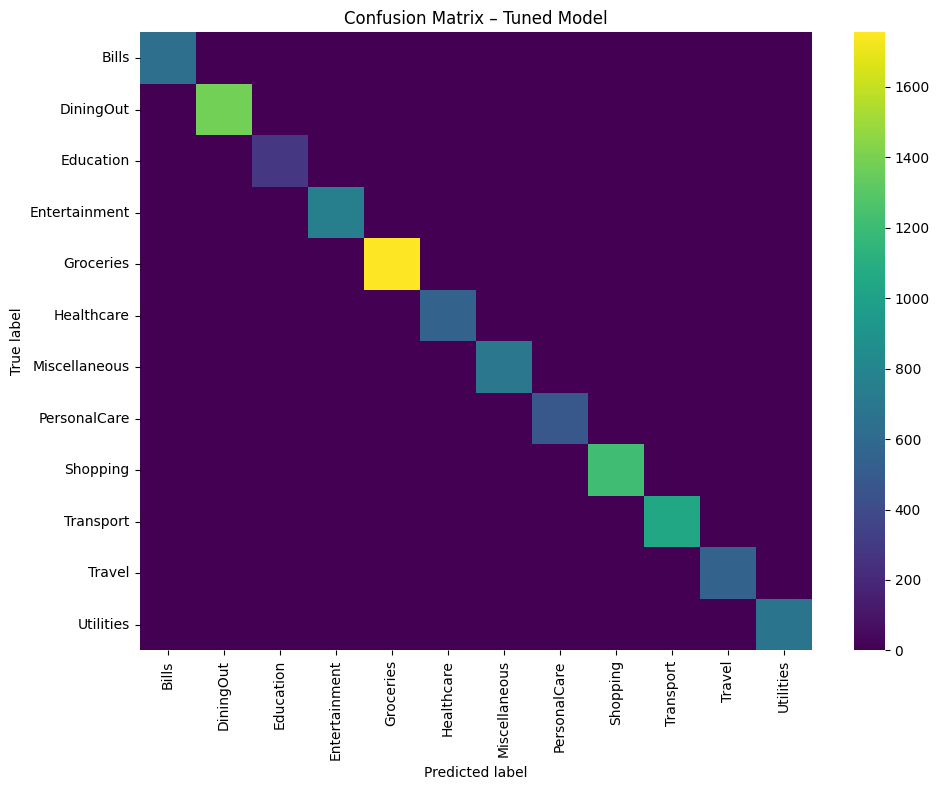

In [ ]:
# 7. Confusion matrix heatmap for demo
# ------------------------------------
# Visualize how the tuned model behaves across all categories.
# Rows = true labels, columns = predicted labels.

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix using encoded labels
# y_true_enc and y_pred_enc must follow the same ID order in mp.LABEL_CLASSES
cm = confusion_matrix(
    y_true_enc,
    y_pred_enc,
    labels=list(range(len(mp.LABEL_CLASSES))),
)

plt.figure(figsize=(10, 8))

# Heatmap (kept clean for presentation)
sns.heatmap(
    cm,
    annot=False,
    cmap="viridis",
    xticklabels=mp.LABEL_CLASSES,   # predicted
    yticklabels=mp.LABEL_CLASSES,   # true
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix – Tuned Model")
plt.tight_layout()
plt.show()

## 8. Inspect a few random predictions (true vs. predicted)

To make the tuned model’s behavior more interpretable, we sample a few
random transactions and compare:

- The **true spending category**
- The **model’s predicted category**
- Key context fields (vendor, description, amount)

This qualitative check helps confirm whether the predictions make sense
intuitively and highlights cases where visually similar vendors or
amount patterns may lead to misclassification.

In [11]:
# 8. Show a few random rows: true vs. predicted
# ---------------------------------------------
# We randomly sample a handful of transactions and compare:
#   - original vendor / description
#   - amount spent
#   - true category label
#   - predicted category label

rng = np.random.default_rng(seed=42)  # reproducible sampling

n_examples = 5
sample_idx = rng.choice(len(df), size=n_examples, replace=False)

print("===== Example predictions on random transactions =====\n")

for i in sample_idx:
    # Encoded labels (0, 1, 2, ...)
    true_id = int(y_true_enc[i])
    pred_id = int(y_pred_enc[i])

    # Map to human-readable labels using the saved class order
    true_label = mp.LABEL_CLASSES[true_id]
    pred_label = mp.LABEL_CLASSES[pred_id]

    row = df.loc[i]

    vendor = row["vendor"] if "vendor" in df.columns else "N/A"
    desc = row["description"] if "description" in df.columns else "N/A"
    amount = row["amount"] if "amount" in df.columns else 0.0

    print(f"Row {i:4d} | Vendor: {str(vendor)[:30]:30s} | "
          f"Amount: ${float(amount):8.2f}")
    print(f"   True      : {true_label}")
    print(f"   Predicted : {pred_label}\n")

===== Example predictions on random transactions =====

Row 7737 | Vendor: Costco                         | Amount: $   50.62
   True      : Groceries
   Predicted : Groceries

Row 4388 | Vendor: DiningOut Store 058            | Amount: $   36.83
   True      : DiningOut
   Predicted : DiningOut

Row 6544 | Vendor: Entertainment Store 139        | Amount: $   73.66
   True      : Entertainment
   Predicted : Entertainment

Row  892 | Vendor: Utilities Store 005            | Amount: $   36.65
   True      : PersonalCare
   Predicted : PersonalCare

Row 4330 | Vendor: Groceries Store 036            | Amount: $   92.42
   True      : Groceries
   Predicted : Groceries



## 8. Summary of Inference Demo

In this notebook, we demonstrated how to use the **final tuned expense-category model** 
(a single unified Logistic Regression pipeline) to perform **real-world inference on new transactions**.

Because our production model encapsulates **all preprocessing steps** inside a single scikit-learn Pipeline 
(TF-IDF vectorizers, StandardScaler, OneHotEncoder, and Logistic Regression),  
the inference workflow becomes simple, reliable, and identical to how the model was trained.

### Key Takeaways

#### **Model Loading**
- We successfully loaded the trained unified pipeline from `models/best_category_model.pkl`.
- This pipeline already contains:
  - TF-IDF vectorizers for vendor + description  
  - StandardScaler for the `amount` column  
  - OneHotEncoder for payment method, city, and state  
  - Tuned Logistic Regression classifier  
- Because everything is bundled, **no separate scaler or preprocessing utilities are required** at inference time.

#### **Feature Reconstruction**
- We rebuilt the **same feature matrix schema** used during model tuning.
- This ensures that inference remains consistent and prevents column-ordering mismatches.

#### **Prediction Workflow**
- Using the trained pipeline, we generated predictions directly from the processed transaction DataFrame.
- We compared model predictions to true labels using:
  - Overall accuracy  
  - Per-category precision/recall/F1  
  - Confusion matrix heatmap  
- The results confirm that the tuned model behaves identically to how it performed in training and validation.

#### **Qualitative Validation**
- We inspected several random transactions and compared:
  - Vendor + description text  
  - Amount  
  - **True category**  
  - **Model-predicted category**  
- These examples show where the model performs strongly (e.g., Groceries, Bills) and where similar categories may be confused (e.g., Shopping vs. DiningOut).

---

### Final Notes

This inference notebook demonstrates that the final model is:
- **Robust** — applies identical preprocessing to any dataset without manual intervention  
- **Portable** — can be plugged into a Gradio app, web API, or downstream analytics pipeline  
- **Consistent** — ensures that real-world predictions match training-time behavior  
- **Ready for deployment** — ideal for your final project demo and for Codabench evaluation  

With reproducible artifacts, unified preprocessing, and predictable inference steps, this workflow establishes a strong foundation for the final project submission.